In [1]:
from pathlib import Path
import pandas as pd
from itertools import product
import copy

from pipeline.hepler_functions import log_error, log_success, save_files, print_df, normalize_statistics_df, highlight_row
from pipeline.data_preprocessing import Preprocessing
from pipeline.data_inconsistency import Inconsistency
from pipeline.data_visualization import Visualization
from pipeline.selection_and_refinement import SelectionAndRefinement

In [2]:
BASE_DIR = "data"

# Stores statistics of records excluded during data processing
record_statistics = pd.DataFrame(columns=[ "Academic year", "Semester", "Total rows", "Excluded rows", "Remaining rows" ])

# Stores statistics of records excluded by course and system per semester.
record_courses_statistics, record_systems_statistics = [], []

# **1. Data Preprocessing**

Quá trình tiền xử lý dữ liệu bao gồm các bước:
- Thống nhất các giá trị trong cột 'Điện thoại' và 'Lớp' về kiểu dữ liệu chuỗi.
- Không xét đến các dòng dữ liệu mà:
    - Cột 'Tên môn' chứa giá trị 'Sinh hoạt chủ nhiệm'
    - Cột 'Hệ đào tạo'/'Hệ ĐT' chứa các giá trị 'Khánh Hòa/'Nha Trang'/'Bảo Lộc'/'4+1'
    - Cột 'Phòng' chứa giá trị 'TRUCTUYEN'

In [3]:
def remove_rows_by_keywords(data, columns, keywords):
    for c, k in product(columns, keywords):
        if c in data.columns:
            data = Preprocessing.remove_rows(data, c, k)
    return data

In [4]:
input_path = f"{BASE_DIR}/raw_data"
output_path = f"{BASE_DIR}/normalized_data"

# Process all Excel files under the data/raw_data directory.
for file_path in Path(input_path).rglob("TKB.xlsx"):
    components = file_path.parts
    year = components[2]
    semester = components[3]
    print(f"\n📂 Academic year: {year}, Semester: {semester}")

    try:              
        xls = pd.ExcelFile(file_path)
        
        timetable = pd.read_excel(
            xls,
            sheet_name=Preprocessing.find_final_sheet(xls),
            dtype=str,
            keep_default_na=False
        )
        
        # Record data for summary statistics
        statistics = pd.DataFrame([{
            "Academic year": year,
            "Semester": semester,
            "Total rows": len(timetable),
            "Excluded rows": 0,
            "Remaining rows": 0
        }])
        
        # ==============================
        # Preprocess the timetable
        #===============================
        
        # Convert column values to strings
        columns = ["Điện thoại", "Lớp"]
        timetable = Preprocessing.normalize_string_columns(timetable, columns)          
        
        # Remove rows based on keywords in specific columns
        columns = ["Tên môn"] 
        keywords = ["Sinh hoạt chủ nhiệm", "Kiến tập công nghiệp", "Thực tập nghề nghiệp"]
        timetable = remove_rows_by_keywords(timetable, columns, keywords) 
        
        columns = ["Hệ đào tạo", "Hệ ĐT"] 
        keywords = ["Khánh Hòa", "Nha Trang", "Bảo Lộc", "4+1"]            
        timetable = remove_rows_by_keywords(timetable, columns, keywords)
        
        columns = ["Phòng"] 
        keywords = ["TRUCTUYEN"]            
        timetable = remove_rows_by_keywords(timetable, columns, keywords)
        
        # Remove classes with no students
        timetable = Preprocessing.remove_rows_by_numeric_condition(timetable, "Sỉ số")
        
        # Count invalid emails in important columns
        print("\n")
        columns = ["Email cá nhân", "Email TDTU"]
        Preprocessing.count_invalid_emails(timetable, columns)   
        
        # Save the cleaned timetable and record statistics
        save_files(file_path, timetable, input_path, output_path, "xlsx")
        statistics.loc[0, "Excluded rows"] = statistics.at[0, "Total rows"] - len(timetable)
        statistics.loc[0, "Remaining rows"] = len(timetable)
        record_statistics = pd.concat(
            [record_statistics, statistics],
            ignore_index=True
        )
        print("\n\n")
        
    except Exception as e:
        log_error(f"Error reading file {file_path.name}: {e}")
        print("Path:", file_path)


📂 Academic year: 2022-2023, Semester: HK1
 Removed 19 rows containing 'Sinh hoạt chủ nhiệm' in column 'Tên môn'.
 Removed 0 rows containing 'Kiến tập công nghiệp' in column 'Tên môn'.
 Removed 1 rows containing 'Thực tập nghề nghiệp' in column 'Tên môn'.
 Removed 0 rows containing 'Khánh Hòa' in column 'Hệ ĐT'.
 Removed 94 rows containing 'Nha Trang' in column 'Hệ ĐT'.
 Removed 70 rows containing 'Bảo Lộc' in column 'Hệ ĐT'.
 Removed 0 rows containing '4+1' in column 'Hệ ĐT'.
 Removed 0 rows containing 'TRUCTUYEN' in column 'Phòng'.
 Removed 0 rows with value 0 in column 'Sỉ số'.


 Email cá nhân: All emails valid.
 Email TDTU: All emails valid.
 Saved: data\normalized_data\2022-2023\HK1\TKB.xlsx.




📂 Academic year: 2022-2023, Semester: HK2
 Removed 24 rows containing 'Sinh hoạt chủ nhiệm' in column 'Tên môn'.
 Removed 0 rows containing 'Kiến tập công nghiệp' in column 'Tên môn'.
 Removed 4 rows containing 'Thực tập nghề nghiệp' in column 'Tên môn'.
 Removed 0 rows containing 'Khánh

# **2. Data Inconsistency**

Quá trình xử lý dữ liệu mâu thuẫn bao gồm các bước:
- Phát hiện các dòng dữ liệu mâu thuẫn với nhau:
    - Một giảng viên bất kỳ có dạy nhiều hơn một lớp tại một thời điểm hay không.
    - Một phòng học bất kỳ có được phân nhiều hơn một lớp tại một thời điểm hay không.
- Với mỗi tập chứa các dòng dữ liệu mâu thuẫn, I = {i_0, i_1,..., i_n}, việc lựa chọn dòng dữ liệu nào được giữ lại thực hiện theo các tiêu chí sau:    
    - Nếu tồn tại dòng dữ liệu i_j sao cho việc giữ lại i_j đồng thời làm tối thiểu hóa:
        - tổng tỷ lệ dữ liệu mất mát theo môn học (của các dòng dữ liệu còn lại trong I), và
        - tổng tỷ lệ dữ liệu mất mát theo hệ đào tạo (của các dòng dữ liệu còn lại trong I),  
    thì ta giữ lại dòng dữ liệu i_j.

    - Trong các trường hợp còn lại, giữ lại dòng dữ liệu i_j sao cho tổng của hai tỷ lệ mất mát trên là nhỏ nhất.

In [5]:
def detect_classroom_overlap(timetable, cols, file_path):    
    grouped_duplicate_data = Inconsistency.check_for_duplication(timetable, cols)
    Inconsistency.mark_duplicates(grouped_duplicate_data, file_path)
    return grouped_duplicate_data

In [6]:
input_path = f"{BASE_DIR}/normalized_data"

# Process all Excel files under the data/normalized_data directory.
for file_path in Path(input_path).rglob("TKB.xlsx"):
    components = file_path.parts
    year = components[2]
    semester = components[3]
    print(f"\n📂 Academic year: {year}, Semester: {semester}")

    try:      
        timetable = pd.read_excel(file_path)
        
        # Record data for summary statistics
        statistics = pd.DataFrame([{
            "Academic year": year,
            "Semester": semester,
            "Total rows": len(timetable),
            "Excluded rows": 0,
            "Remaining rows": 0
        }])
        
        # ==============================
        # Deduplicate the timetable
        #===============================        
        # Check if there are any lecturers who have overlapping teaching hours.
        session = next((s for s in ["Ca", "Tiết"] if s in timetable.columns), None)
        grouped_duplicate_data_1 = detect_classroom_overlap(timetable, ["Thứ", session, "Email TDTU"], file_path)
        # save_files(file_path, grouped_duplicate_data_1, input_path, output_path)
        
        # Check if any classrooms have overlapping teaching times
        grouped_duplicate_data_2 = detect_classroom_overlap(timetable, ["Thứ", session, "Phòng"], file_path)
        # save_files(file_path, grouped_duplicate_data_2, input_path, output_path) 
        
        output_path = f"{BASE_DIR}/duplicate_data"
        merged_groups = list(grouped_duplicate_data_1) + list(grouped_duplicate_data_2)  
        save_files(file_path, merged_groups, input_path, output_path) 

        # Handle conflicting data
        courses_statistics, systems_statistics = Inconsistency.prepare_statistics(timetable)
            
        for idx, (key, group) in enumerate(merged_groups, start=1):
            testing_timetable = copy.deepcopy(timetable)
            
            print(f"\n====== Processing duplicate dataFrame {idx} ======")
            # print_df(group)
            tmp_courses_statistics, tmp_systems_statistics = [], []
            
            try:
                for i, row in group.iterrows():
                    Inconsistency.find_row(timetable, row)   
                    remaining_rows = group.drop(i)         
                    testing_timetable = Inconsistency.remove_rows(testing_timetable, remaining_rows)
                    
                    # Save statistics to identify classes for removal.
                    COURSE_STATISTICS_CONFIG = {
                        "col_in_timetable": "Mã MH",
                        "col_in_statistics": "Course ID"
                    }
                    
                    tmp_courses_statistics.append((i, Inconsistency.get_difference_statistics(testing_timetable, courses_statistics, remaining_rows, COURSE_STATISTICS_CONFIG)))
                    # styled_course = highlight_row(df_course, "Course ID", remaining_rows["Mã MH"].unique().tolist())
                    # display(styled_course)

                    SYSTEM_STATISTICS_CONFIG = {
                        "col_in_timetable": "Hệ ĐT",
                        "col_in_statistics": "Education system"
                    }
                    
                    tmp_systems_statistics.append((i, Inconsistency.get_difference_statistics(testing_timetable, systems_statistics, remaining_rows, SYSTEM_STATISTICS_CONFIG)))
                    # styled_system = highlight_row(df_system, "Education system", remaining_rows["Hệ ĐT"].unique().tolist())
                    # display(styled_system)
                
                    if (Inconsistency.is_single_class(group)):
                        break    
                        
                # print_diffs(tmp_courses_statistics, tmp_systems_statistics)
                timetable = Inconsistency.update_timetable(timetable, group, tmp_courses_statistics, tmp_systems_statistics)

            except Exception as error:
                log_error(f"Error processing file {file_path.name}: {error}")                 
        
        output_path = f"{BASE_DIR}/final_data"
        save_files(file_path, timetable, input_path, output_path, "xlsx")
                    
        # Record statistics after inconsistency    
        courses_statistics, systems_statistics = Inconsistency.update_statistics(timetable, courses_statistics, systems_statistics)
        record_courses_statistics.append(courses_statistics)
        record_systems_statistics.append(systems_statistics)
            
        statistics.loc[0, "Excluded rows"] = statistics.at[0, "Total rows"] - len(timetable)
        statistics.loc[0, "Remaining rows"] = len(timetable)
        record_statistics = pd.concat(
            [record_statistics, statistics],
            ignore_index=True
        )  
        print("\n\n")
    
    except Exception as e:
        log_error(f"Error handling file {file_path.name}: {e}")
        print("Path:", file_path)


📂 Academic year: 2022-2023, Semester: HK1
 Highlighted 52 duplicate rows in data\normalized_data\2022-2023\HK1\TKB.xlsx..
 Highlighted 22 duplicate rows in data\normalized_data\2022-2023\HK1\TKB.xlsx..
 Saved: data\duplicate_data\2022-2023\HK1\TKB.parquet.

====== Processing duplicate dataFrame 1 ======
 Deleted 2 row(s).
 Deleted 1 row(s).
 Deleted 0 row(s).
 Deleted 2 row(s).

====== Processing duplicate dataFrame 2 ======
 Deleted 1 row(s).
 Deleted 1 row(s).
 Deleted 1 row(s).

====== Processing duplicate dataFrame 3 ======
 Deleted 1 row(s).
 Deleted 1 row(s).

====== Processing duplicate dataFrame 4 ======
 Deleted 1 row(s).
 Deleted 1 row(s).
 Deleted 1 row(s).

====== Processing duplicate dataFrame 5 ======
 Deleted 2 row(s).
 Deleted 1 row(s).
 Deleted 0 row(s).
 Deleted 2 row(s).

====== Processing duplicate dataFrame 6 ======
 Deleted 1 row(s).
 Deleted 1 row(s).
 Deleted 1 row(s).

====== Processing duplicate dataFrame 7 ======
 Deleted 1 row(s).
 Deleted 1 row(s).
 Delete

# **3. Data Visualization**

Cuối cùng, các thao tác trực quan hóa dữ liệu bao gồm:
- Trực quan hóa tổng số dòng dữ liệu bị loại trừ sau khi kết thúc 2 quá trình xử lý.
- Trực quan hóa số dòng dữ liệu bị loại trừ tại mỗi bước xử lý.
- Trực quan hóa chi tiết số dòng dữ liệu bị loại trừ tại bước xử lý thứ 2.

### 3.1 Statistics on the total number of records excluded per semester.

d:\IT PROJECT\UCTP\EDA\pipeline\data_visualization.py:169: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result, new_rows], ignore_index=True)


,Academic year,Semester,Total rows,Excluded rows,Remaining rows,Percentage of excluded data
0,2022-2023,HK1,694,217,477,31.3%
1,2022-2023,HK2,704,337,367,47.9%
2,2023-2024,HK1,708,226,482,31.9%
3,2023-2024,HK2,446,115,331,25.8%


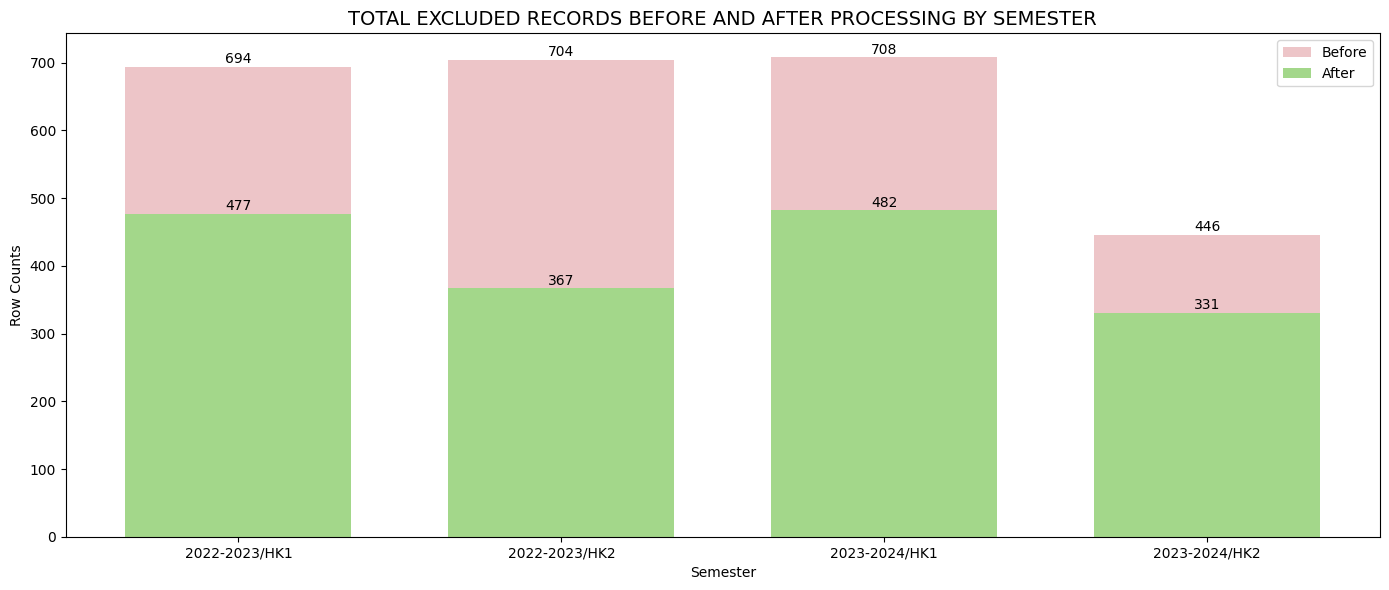

In [7]:
result = Visualization.count_total_excluded_data(record_statistics)
result = normalize_statistics_df(result)
print_df(result)

Visualization.display_chart_for_overall_summary(result)

### 3.2 Statistics on the number of records excluded at each processing stages

 
📂 Academic year: 2022-2023, Semester: HK1.


d:\IT PROJECT\UCTP\EDA\pipeline\data_visualization.py:227: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_rows], ignore_index=True)
d:\IT PROJECT\UCTP\EDA\pipeline\data_visualization.py:227: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_rows], ignore_index=True)
d:\IT PROJECT\UCTP\EDA\pipeline\data_visualization.py:227: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will n

,Stage,Excluded rows,Remaining rows,Percentage of excluded data
0,Rows excluded due to data preprocessing,184,510,26.5%
1,Rows excluded due to data inconsistency,33,477,4.8%
2,Total,217,,31.3%


 
📂 Academic year: 2022-2023, Semester: HK1.


,Stage,Excluded rows,Remaining rows,Percentage of excluded data
0,Rows excluded due to data preprocessing,306,398,43.5%
1,Rows excluded due to data inconsistency,31,367,4.4%
2,Total,337,,47.9%


 
📂 Academic year: 2022-2023, Semester: HK1.


,Stage,Excluded rows,Remaining rows,Percentage of excluded data
0,Rows excluded due to data preprocessing,168,540,23.7%
1,Rows excluded due to data inconsistency,58,482,8.2%
2,Total,226,,31.9%


 
📂 Academic year: 2022-2023, Semester: HK1.


,Stage,Excluded rows,Remaining rows,Percentage of excluded data
0,Rows excluded due to data preprocessing,109,337,24.4%
1,Rows excluded due to data inconsistency,6,331,1.3%
2,Total,115,,25.8%


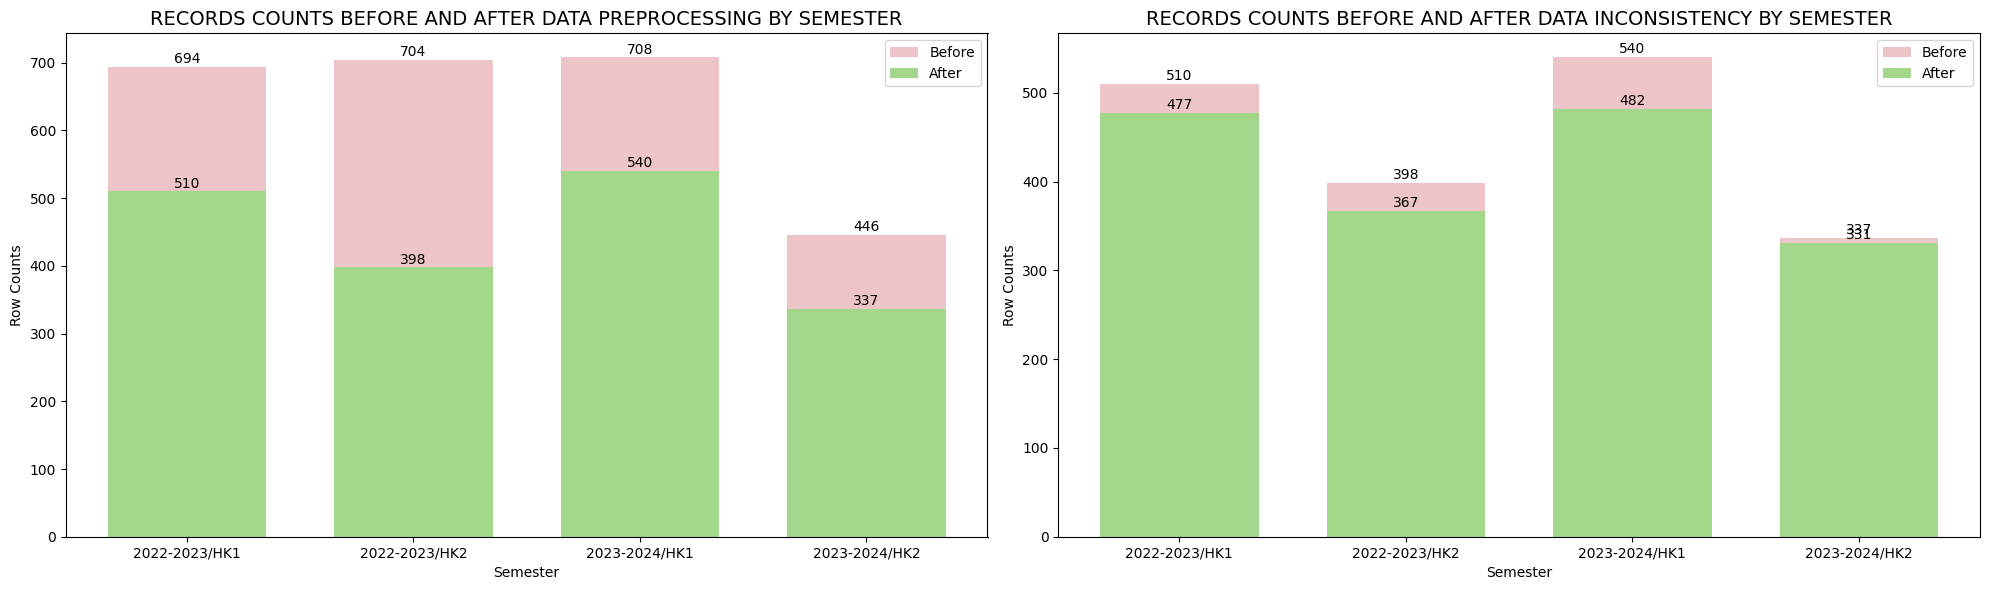

In [8]:
result = Visualization.count_excluded_data(record_statistics)

idx = 0
for r in result:
    year = record_statistics.at[idx, "Academic year"]
    semester = record_statistics.at[idx, "Semester"]
    log_success(f"\n📂 Academic year: {year}, Semester: {semester}")
    each_semester = normalize_statistics_df(r)
    print_df(each_semester)
    
Visualization.display_chart_for_each_stages(record_statistics)

### 3.3 Statistics on the number of records excluded during Data inconsistency stage

In [9]:
# Apply percentage formatting to selected columns.
record_courses_statistics = [normalize_statistics_df(df) for df in record_courses_statistics]
record_systems_statistics = [normalize_statistics_df(df) for df in record_systems_statistics]

In [10]:
for i in range(len(record_courses_statistics)):
    year = record_statistics.at[i, "Academic year"]
    semester = record_statistics.at[i, "Semester"]
    log_success(f"\n📂 Academic year: {year}, Semester: {semester} - Course Statistics")
    
    display(highlight_row(record_systems_statistics[i]))
    display(highlight_row(record_courses_statistics[i]))
    print("\n\n")

 
📂 Academic year: 2022-2023, Semester: HK1 - Course Statistics.


,Education system,Classes before cleaning,Percentage before,Classes after cleaning,Percentage after,Difference
0,Tiêu chuẩn,261,100.0%,247,94.6%,5.4%
1,CLC 50% T.A,198,100.0%,183,92.4%,7.6%
2,CLC 100% T.A,49,100.0%,45,91.8%,8.2%
3,Liên kết,2,100.0%,2,100.0%,0.0%


,Course name,Course ID,Classes before cleaning,Percentage before,Classes after cleaning,Percentage after,Difference
0,Cấu trúc rời rạc,501044,5,100.0%,5,100.0%,0.0%
1,Lập trình C,501046,4,100.0%,4,100.0%,0.0%
2,Công nghệ phần mềm,502045,33,100.0%,28,84.8%,15.2%
3,Nhập môn Mạng máy tính,502046,8,100.0%,8,100.0%,0.0%
4,Nhập môn hệ điều hành,502047,8,100.0%,8,100.0%,0.0%
5,Nhập môn tính toán đa phương tiện,502048,1,100.0%,1,100.0%,0.0%
6,Nhập môn Bảo mật thông tin,502049,5,100.0%,5,100.0%,0.0%
7,Phân tích và thiết kế yêu cầu,502050,1,100.0%,1,100.0%,0.0%
8,Hệ cơ sở dữ liệu,502051,34,100.0%,34,100.0%,0.0%
9,Phát triển hệ thống thông tin doanh nghiệp,502052,7,100.0%,7,100.0%,0.0%





 
📂 Academic year: 2022-2023, Semester: HK2 - Course Statistics.


,Education system,Classes before cleaning,Percentage before,Classes after cleaning,Percentage after,Difference
0,CLC 50% T.A,163,100.0%,147,90.2%,9.8%
1,CLC 100% T.A,29,100.0%,29,100.0%,0.0%
2,Tiêu chuẩn,206,100.0%,191,92.7%,7.3%


...

,Education system,Classes before cleaning,Percentage before,Classes after cleaning,Percentage after,Difference
0,Tiêu chuẩn,253,100.0%,232,91.7%,8.3%
1,CLC 50%,87,100.0%,68,78.2%,21.8%
2,CLC 100%,39,100.0%,29,74.4%,25.6%
3,Liên kết,9,100.0%,7,77.8%,22.2%
4,CTCLC,120,100.0%,115,95.8%,4.2%
5,ĐHTA,32,100.0%,31,96.9%,3.1%


,Course name,Course ID,Classes before cleaning,Percentage before,Classes after cleaning,Percentage after,Difference
0,Giải tích ứng dụng cho Công nghệ thông tin,501031,53,100.0%,48,90.6%,9.4%
1,Phương pháp lập trình,501042,65,100.0%,47,72.3%,27.7%
2,Lập trình C,501046,3,100.0%,3,100.0%,0.0%
3,Nhập môn Phân tích kinh doanh,501049,1,100.0%,1,100.0%,0.0%
4,Tổ chức máy tính,502044,59,100.0%,43,72.9%,27.1%
5,Công nghệ phần mềm,502045,3,100.0%,3,100.0%,0.0%
6,Nhập môn Mạng máy tính,502046,13,100.0%,12,92.3%,7.7%
7,Nhập môn hệ điều hành,502047,6,100.0%,6,100.0%,0.0%
8,Nhập môn Bảo mật thông tin,502049,6,100.0%,5,83.3%,16.7%
9,Phân tích và thiết kế yêu cầu,502050,6,100.0%,6,100.0%,0.0%





 
📂 Academic year: 2023-2024, Semester: HK2 - Course Statistics.


,Education system,Classes before cleaning,Percentage before,Classes after cleaning,Percentage after,Difference
0,CTCLC,124,100.0%,122,98.4%,1.6%
1,ĐHTA,46,100.0%,43,93.5%,6.5%
2,Tiêu chuẩn,159,100.0%,158,99.4%,0.6%
3,Liên kết,8,100.0%,8,100.0%,0.0%


,Course name,Course ID,Classes before cleaning,Percentage before,Classes after cleaning,Percentage after,Difference
0,Đại số tuyến tính cho Công nghệ thông tin,501032,35,100.0%,34,97.1%,2.9%
1,Giải tích ứng dụng cho Công nghệ thông tin 2,501033,2,100.0%,2,100.0%,0.0%
2,Cấu trúc rời rạc,501044,36,100.0%,34,94.4%,5.6%
3,Lập trình C,501046,3,100.0%,3,100.0%,0.0%
4,Công nghệ phần mềm,502045,21,100.0%,21,100.0%,0.0%
5,Nhập môn Mạng máy tính,502046,20,100.0%,20,100.0%,0.0%
6,Nhập môn hệ điều hành,502047,29,100.0%,29,100.0%,0.0%
7,Nhập môn Bảo mật thông tin,502049,5,100.0%,5,100.0%,0.0%
8,Phân tích và thiết kế yêu cầu,502050,7,100.0%,7,100.0%,0.0%
9,Hệ cơ sở dữ liệu,502051,2,100.0%,2,100.0%,0.0%


# **4. Attribute selection and refinement**

Tóm lại, dữ liệu trước khi được dùng để huấn luyện cần trải qua 2 bước xử lý:
- Tiền xử lý dữ liệu.
- Xử lý dữ liệu mâu thuẫn.

Tuy nhiên, để phục vụ cho việc trực quan hóa TKB và hỗ trợ cho các tác tử AI có thể 'học' hiệu quả hơn, ta tiến hành :
- Trích chọn 12 đặc trưng cơ bản nhất thể hiện cho một thời khóa biểu.
- Cố định thứ tự các đặc trưng.
- Đánh mã tổ là 0 cho các lớp lý thuyết.
- Chuyển định dạng file sang JSON

In [11]:
input_path = f"{BASE_DIR}/final_data"
output_path = f"{BASE_DIR}/training_ready_data"

for file_path in Path(input_path).rglob("TKB.xlsx"):
    components = file_path.parts
    year = components[2]
    semester = components[3]
    print(f"\n📂 Academic year: {year}, Semester: {semester}")

    try:      
        timetable = pd.read_excel(file_path)
        
        # ==============================
        # Attribute selection and refinement
        #===============================
        
        # Select only the columns required for training
        cols = SelectionAndRefinement.get_matching_columns(timetable)
        timetable = timetable[cols]
        
        # Rename columns to standard names
        timetable = SelectionAndRefinement.rename_columns(timetable)
        
        # Fill missing group codes
        timetable = SelectionAndRefinement.fill_missing_group_code(timetable)
        
        # Check for missing values
        SelectionAndRefinement.check_missing(timetable)
        
        # Enforce correct data types for each column
        timetable = SelectionAndRefinement.enforce_column_types(timetable)
        
        # Save the final training-ready timetable
        SelectionAndRefinement.save_files(file_path, timetable, input_path, output_path)        
        print("\n")
    
    except Exception as e:
        log_error(f"Error handling file {file_path.name}: {e}")
        print("Path:", file_path)


📂 Academic year: 2022-2023, Semester: HK1
 No missing values found!.
 Saved: data\training_ready_data\2022-2023\HK1\timetable.json.



📂 Academic year: 2022-2023, Semester: HK2
 No missing values found!.
 Saved: data\training_ready_data\2022-2023\HK2\timetable.json.



📂 Academic year: 2023-2024, Semester: HK1
 No missing values found!.
 Saved: data\training_ready_data\2023-2024\HK1\timetable.json.



📂 Academic year: 2023-2024, Semester: HK2
 No missing values found!.
 Saved: data\training_ready_data\2023-2024\HK2\timetable.json.


